<a href="https://colab.research.google.com/github/Nyauntu/Data-science-practice/blob/main/Nyauntu_PatientNoShows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW3: Predicting Patient No-Shows

### Background

You've been hired as the manager of SHMC, a medical center in Brazil. As part of its business model, SHMC usually employs doctors on demand, meaning that doctors are asked to come only when there are appointments. However, once a doctor has been asked to come, you must pay him or her regardless of whether the patient shows up or not. You want to use data on previous appointments to figure out whether you can predict which patients are going to show up, so that you can plan better how many doctors to call.

[The data can be downloaded at this link](https://drive.google.com/uc?download=export&id=1iM0CSzfNckc565zwpb4VpHjEVLgckLPE) in a file called SHMC_NoShows.csv.


Here are some libraries you will need

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score


### Loading the data

**1. Load the data referenced by the path above into a pandas data frame. Report on the total number of rows and columns, and show the first few rows in the dataset.**

In [3]:
df = pd.read_csv("SHMC_NoShows.csv")

# shape
print(df.shape)

df.head()

(110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighborhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


Here's a brief summary of the features in the data:

1. PatientId - Identification of a patient.
2. AppointmentID - Identification of each appointment.
3. Gender - Male or female.
4. ScheduledDay - The day someone called or registered the appointment.
6. AppointmentDay - The day of the actual appointment, when the patient has to visit the doctor.
7. Age = How old is the patient.
8. Neighborhood - Place where the patient lives.
9. Scholarship - Whether the patient receives financial help.(0=No, 1=Yes)
10. Hypertension - Whether the patient suffers from hypertension.(0=No, 1=Yes)
11. Diabetes - Whether the patient suffers from diabetes.(0=No, 1=Yes)
12. Alcoholism - Whether the patient suffers from alcoholism.(0=No, 1=Yes)
13. Handicap - Whether the patient is handicapped (0=No, 1=Yes)
14. SMS_received - Whether 1 or more SMS messages were sent to the patient (0=No, 1=Yes)
15. No-show - Whether the patient missed the appointment.

### Exploratory Data Analysis

**2. Make sure Python recognizes `ScheduledDay` and `AppointmentDay` as timestamps by using `.to_datetime()`. What is the earliest and latest date of  AppointmentDay, and calculate the number of days between these two?**

In [4]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

earliest = df['AppointmentDay'].min()
latest = df['AppointmentDay'].max()

print("Earliest:", earliest)
print("Latest:", latest)
print("Days between:", (latest-earliest).days)

Earliest: 2016-04-29 00:00:00+00:00
Latest: 2016-06-08 00:00:00+00:00
Days between: 40


**3. If you take a look at both dates, you will see that `ScheduledDay` includes a specific time with the date, but `AppointmentDay` doesn't. In order to compare both fields more easily, apply `.normalize()` to `ScheduledDay` (i.e., keep only the dates).**

In [5]:
df['ScheduledDay'] = df['ScheduledDay'].dt.normalize()

**4. Create a new feature called 'TimeInAdvance' which is the difference in days between `ScheduledDay` and `AppointmentDay`.  (you may need to apply `dt.days`  to a datetime object to make sure this is a numeric). What is the longest advance time that someone scheduled an appointment? What do you expect the relationship between `TimeInAdvance` and the probability of a No-Show to be?**

In [6]:
df['TimeInAdvance'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

df['TimeInAdvance'].describe()


,TimeInAdvance
count,110527.000000
mean,10.183702
std,15.254996
min,-6.000000
25%,0.000000
50%,4.000000
75%,15.000000
max,179.000000


In [7]:
df['TimeInAdvance'].max()



179

the probability of a no-show increases as the time in advance increases. Patients are more likely to forget or have scheduling conflicts for appointments made months in advance compared to those made for the same or next day.


**5. Explore the data set using EDA functions we have discussed in class.  Look at each feature.  Do any of them contain missing or weird values or outliers that concern you, given the feature descriptions above?  Comment on any unusual values you see in any of the columns.  Remove observations that contain any strange observations you have no explanation for, and report on how many rows were removed.**

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighborhood    110527 non-null  object             
 7   Scholarship     110527 non-null  int64              
 8   Hypertension    110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoholism      110527 non-null  int64              
 11  Handicap        110527 non-null  int64              
 12  SMS_received    110527 non-null  int64              
 13  No-show       

,PatientId,AppointmentID,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,TimeInAdvance
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,10.183702
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,15.254996
min,3.920000e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.000000
25%,4.172615e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173180e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,9.439170e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,15.000000
max,9.999820e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,179.000000


In [9]:
#Issues in the data
#There are five observations in the data where appointments were scheduled after the appointment date, which is impossible.

df[df['TimeInAdvance'] < 0].shape



(5, 15)

In [10]:
#There is 1 row with Age = -1.
df[df['Age'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighborhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show,TimeInAdvance
99832,4.659430e+14,5775010,F,2016-06-06 00:00:00+00:00,2016-06-06 00:00:00+00:00,-1,ROMÃO,0,0,0,0,0,0,No,0


In [11]:
#removing problematic rows
df = df[df['TimeInAdvance'] >= 0]
df = df[df['Age'] >= 0]

**6. Create a new column from `Gender` called `IsFemale` that is 1 if the patient is female and 0 otherwise. Do the same for the No-show variable. It should be 1 if the person didn't show and 0 otherwise. This is your target variable. Drop the original columns for these two.**

In [12]:
df['IsFemale'] = (df['Gender'] == 'F').astype(int)

df['NoShow'] = (df['No-show'] == 'Yes').astype(int)

df.drop(['Gender','No-show'], axis=1, inplace=True)

**7. Now we explore the `Neighborhood` feature.  It is a categorical with many levels (as can be seen from `value_counts`).  To simplify the analysis we are going to create a new verison of `Neighborhood` by re-labelling any neighborhoods that appears LESS THAN 3000 times and give them the label Neighborhood="OTHER".  Show a table of value_counts of your *new* Neighborhood feature. Create dummy variables for your new Neighborhood feature, add the dummies to your data frame, and then drop the original Neighborhood column from the data frame.**

In [13]:
counts = df['Neighborhood'].value_counts()

# Replacing neighborhoods appearing <3000 times
df['Neighborhood'] = df['Neighborhood'].apply(
    lambda x: x if counts[x] >= 3000 else 'OTHER'
)

new_counts = df['Neighborhood'].value_counts()

print("Number of unique neighborhoods after grouping:", df['Neighborhood'].nunique())
print("\nNeighborhood counts:")
print(new_counts)

Number of unique neighborhoods after grouping: 9

Neighborhood counts:
Neighborhood
OTHER              75582
JARDIM CAMBURI      7717
MARIA ORTIZ         5805
RESISTÊNCIA         4430
JARDIM DA PENHA     3877
ITARARÉ             3514
CENTRO              3334
SANTA MARTHA        3131
TABUAZEIRO          3131
Name: count, dtype: int64


In [14]:
dummies = pd.get_dummies(df['Neighborhood'], prefix="NB")

df = pd.concat([df, dummies], axis=1)

df.drop('Neighborhood', axis=1, inplace=True)

**8. There are many patients that have historically made more than one appointment. This data set contains multiple observations per person, so we can use their past appointments as features in predicting whether the current appointment will be a no-show.**

**For example, the fact that a patient has failed to show up in the past may be predictive of the patient not showing up in the future. We want to create a variable that calculates the number of no_shows BEFORE the current appointment.**

**Create a new column called `PreviousNoShows` that for each appointment includes the number of *previous* appointments to which the patient did not show. For example, if the `PatientID` did not show to their first appointment, `PreviousNoShows` should be 0 for the first appointment and 1 for the second one (if there is any). (We have provided code for this part below, but take a look at it to see if it makes sense to you, and edit the code to use your data frame name).**

**Now, create a line plot showing the relationship between PreviousNoShows and No-Show for the current appointment.   For each value of PreviousNoShows, plot the percent of No-Shows for the current appointment (Hint: use `groupby()`).  Does there seem to be a relationship? That is, does the number of PREVIOUS no-shows seem to be predictive of a no-show for the CURRENT appointment?  Comment on what you see.**

In [15]:
#sorting the dataset

df = df.sort_values(['PatientId','ScheduledDay'])

df['PreviousNoShows'] = df.groupby('PatientId')['NoShow'].cumsum() - df['NoShow']

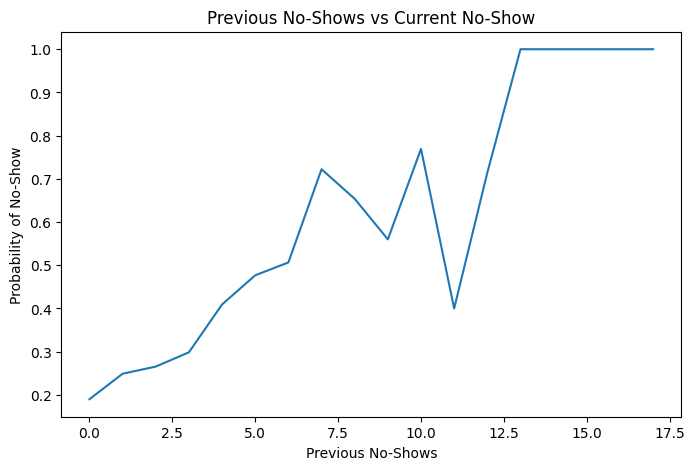

In [16]:
#plotting the relationship
grouped = df.groupby('PreviousNoShows')['NoShow'].mean()

plt.figure(figsize=(8,5))
grouped.plot()
plt.ylabel("Probability of No-Show")
plt.xlabel("Previous No-Shows")
plt.title("Previous No-Shows vs Current No-Show")
plt.show()

Yes, there is a very strong positive relationship between the number of previous no-shows and the probability of a no-show for the current appointment.

### Modelling with Decision Trees

**9. Build a model to predict No-Show using a DecisionTreeClassifier:**
* **First, drop the columns we won't be needing: `PatientId`, `AppointmentID`,
`ScheduledDay`, and `AppointmentDay`.**
* **Split the data into training and test (80/20) - using `random_state=99`.**  
* **Apply 5-fold `GridSearchCV()` *only to the training data* (`X_train` and `y_train`)  to find the optimal values of `max_depth` (search values between 1 and 51 in steps of 10) and `min_samples_split` (search values from 5 to 25 in steps of 5). Use F-measure (aka f1) as the scoring metric.  Report the optimal parameter values AND the optimal F1 score.**


In [17]:
#dropping columns we do not need
df_model = df.drop(['PatientId','AppointmentID','ScheduledDay','AppointmentDay'], axis=1)

X = df_model.drop('NoShow', axis=1)
y = df_model['NoShow']

In [18]:
#splitting the data into training sets and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40
)

In [19]:
#grid search
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': list(range(1,52,10)),
    'min_samples_split': list(range(5,26,5))
}

tree = DecisionTreeClassifier(random_state=99)

grid = GridSearchCV(
    tree,
    param_grid,
    scoring='f1',
    cv=5
)

grid.fit(X_train,y_train)

print("Best parameters:", grid.best_params_)
print("Best F1:", grid.best_score_)

Best parameters: {'max_depth': 41, 'min_samples_split': 5}
Best F1: 0.2815549219573283


The optimal decision tree uses a maximum depth of 41 and a minimum sample split of 5, achieving a cross-validated F1 score of approximately 0.282 on the training data.

The F1 score is relatively low, which suggests that predicting patient no-shows is difficult with the available features.

**10: Assign the optimal model that comes out of `GridSearchCV` to `final_model`.  Plot only the first three levels of the final_model tree, by using `.plot_tree()` with the option `max_depth=3` (see code below).  What are the rules to get to the leaf node that has the HIGHEST probability of NO-SHOW in these first three levels? Comment on these rules, do they make sense to you? are they intuitive?**

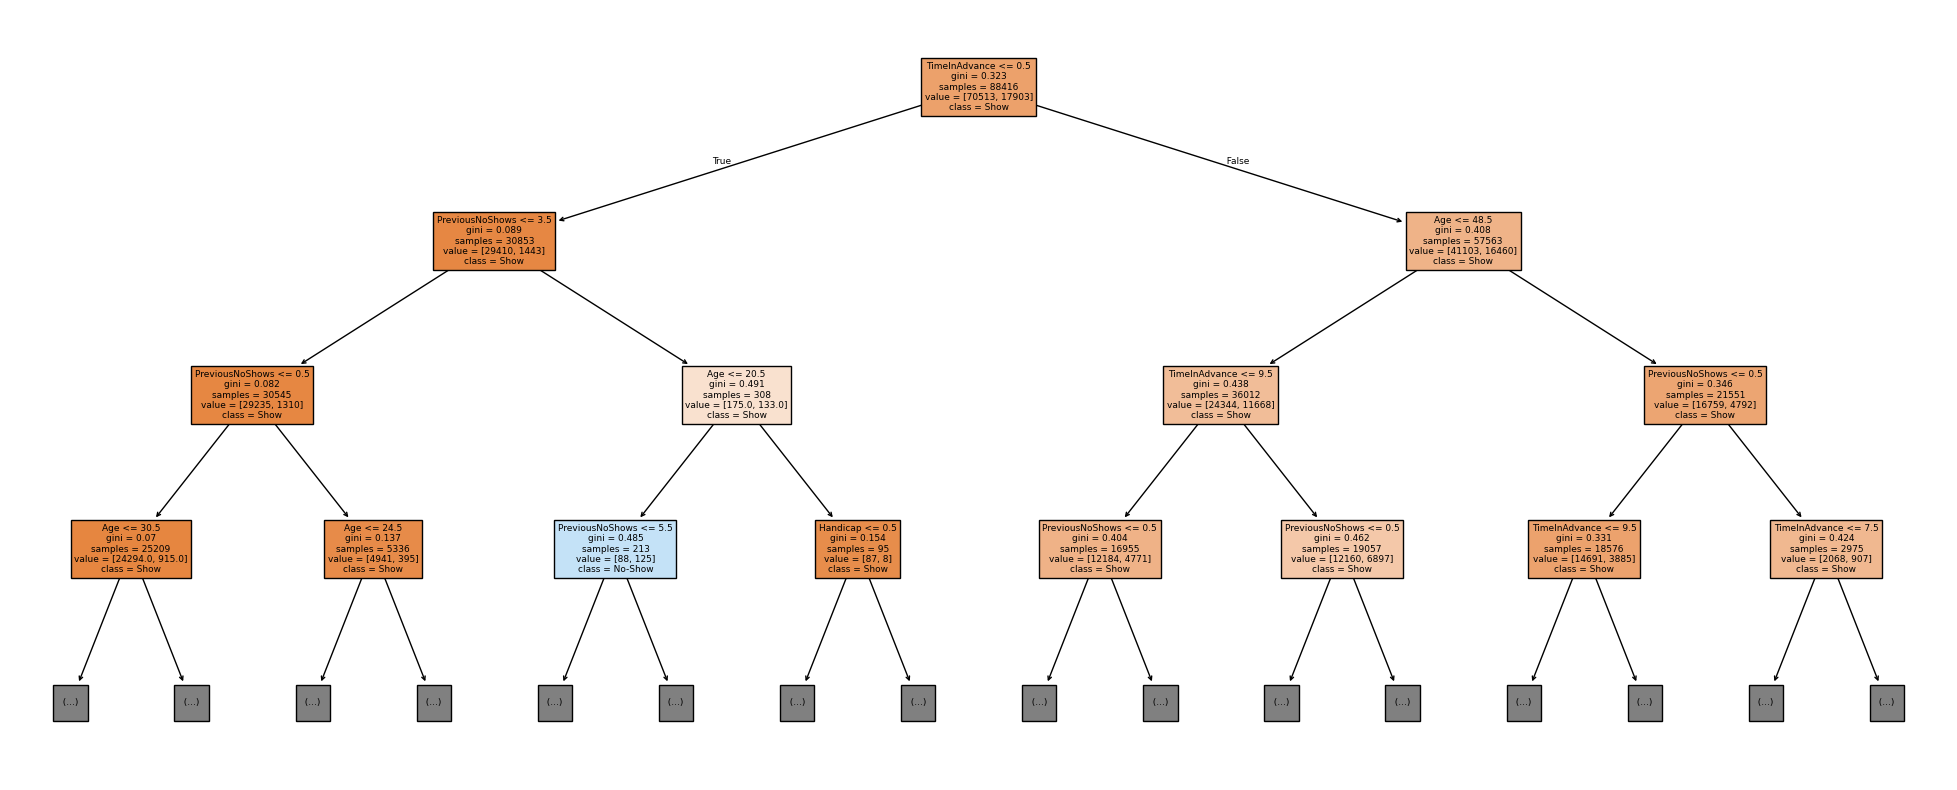

In [20]:
final_model = grid.best_estimator_

plt.figure(figsize=(25,10))
plot_tree(final_model, feature_names=X_train.columns, class_names=['Show', 'No-Show'], filled=True, max_depth=3)
plt.show()

Rules used:
The node with the highest probability of a No-Show is reached when TimeInAdvance ≤ 0.50 (the appointment was scheduled the same day), PreviousNoShows > 3.50 (the patient has missed at least four previous appointments), and Age ≤ 20.50 (the patient is 20 years old or younger). These rules make sense *because* patients who have frequently missed appointments in the past are more likely to miss again, and younger patients may be less consistent with attending appointments, making them a higher no-show risk group.

**11. Calculate the feature importance values for the features in `final_model`.  Comment on each of the top 5 features and discuss how each one impacts no-show probability.  Comment on how you might you deal with this knowledge in making your office more efficient.**

In [33]:
final_model_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=41,
    min_samples_split=5,
    random_state=99
)

final_model_entropy.fit(X_train, y_train)

# importance values are based on Information Gain
importances_ig = final_model_entropy.feature_importances_
#  Getting feature importance values from the model
importances = final_model.feature_importances_

# Creating a DataFrame to map features to their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# sorting the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Printing the top 5 features
print("Top 5 Features:")
print(feature_importance_df.head(5))

Top 5 Features:
            Feature  Importance
7     TimeInAdvance    0.402156
0               Age    0.286620
8          IsFemale    0.044908
18  PreviousNoShows    0.031764
2      Hypertension    0.029087


TimeInAdvance: Longer lead times between scheduling and the appointment increase the likelihood of a patient forgetting or encountering a schedule conflict.

Age:  younger adults are less reliable than children or the elderly.

IsFemale: Gender can reflect differing social and caregiving responsibilities that may impact a patient's ability to prioritize their own medical appointments.

PreviousNoShows: Past behavior is the strongest indicator of future attendance, as patients with a history of missing appointments often face persistent barriers to care.

Hypertension: Patients with chronic conditions like hypertension often have a higher perceived health risk, which generally motivates more consistent attendance at follow-up visits.



My suggestions:
To make the office more efficient, we can use these insights to implement a risk-based scheduling strategy, where high-risk appointments (identified by poor past attendance) receive reminders and strategic overbooking.

**12. Use your `final_model` to predict values for `X_test` to get `y_pred`. Using `y_pred` and `y_test`, calculate precision and recall using the functions `precision_score` and `recall_score`**

In [21]:
# Predicting on test data
y_pred = final_model.predict(X_test)

# Calculating precision and recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.352088948787062
Recall: 0.23690773067331672


## Exploring Different Thresholds

**13. The precision/reall values above were calculated using a threshold of 0.5 (this is the default in the tree fitting function).  As we discussed in class, changing the threshold will have an effect on precision and recall.  Plot boxplots of the predicted probabilities for no-shows and non no-shows in the test set.  Pick a threshold that you think will separate the two best.**


In [22]:
# Predicting on test data
y_pred = final_model.predict(X_test)

# Calculating precision and recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.352088948787062
Recall: 0.23690773067331672


<Figure size 800x500 with 0 Axes>

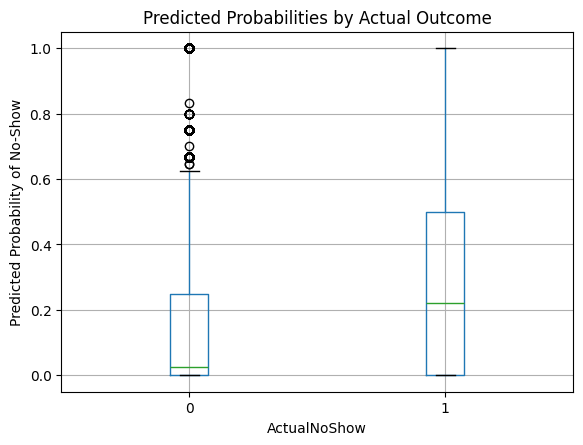

In [23]:
y_prob = final_model.predict_proba(X_test)[:,1]

# creating dataframe for plotting
prob_df = pd.DataFrame({
    'ActualNoShow': y_test,
    'PredictedProb': y_prob
})

# boxplot
plt.figure(figsize=(8,5))
prob_df.boxplot(column='PredictedProb', by='ActualNoShow')
plt.ylabel("Predicted Probability of No-Show")
plt.title("Predicted Probabilities by Actual Outcome")
plt.suptitle("")
plt.show()

The boxplots show the distribution of predicted no-show probabilities for the two groups.

Patients who showed up (0) have very low predicted probabilities, with a median around 0.024 and most values below 0.25. Patients who missed their appointments (1) have higher predicted probabilities, with a median around 0.222 and the third quartile near 0.50.

Although there is some overlap between the groups, no-show patients generally receive higher predicted probabilities meaning a lower threshold than the default 0.50, such as 0.30, may better separate the two groups and help identify more potential no-shows.

**14. Calculate precision and recall for your new threshold and compare it to the precision/recall for the default threshold of 0.5.  Comment on the tradeoff between the two thresholds and how it changes false positives and negatives.  Which threshold would you choose and why?**

hanging the threshold from 0.5 to 0.3 makes the model label a patient as a no-show even when the probability is only 30%. As a result, recall increases from 33% to 42%, meaning the model identifies more patients who would miss their appointments. However, precision decreases because there are more false positives.

Lowering the threshold increases false positives (predicting a no-show when the patient actually attends) but reduces false negatives (missing actual no-shows). I would choose the 0.3 threshold because identifying more potential no-shows helps the clinic manage scheduling more efficiently.